# Commercial Dimension — EDA

Explorative Analyse der Gewerbe-Feature-Matrix (`feature_matrix_commercial.csv`, 542 PLR × 60 Features).
Aufbau parallel zur Real-Estate-Dimension:

1. **Verteilungen** — Histogramme, reine Bestandsaufnahme (Schiefe/NaN/Median als Info, *noch keine* Transformation)
2. Korrelationen (Spearman) — Redundanzen finden
3. Reliability / Flags — `has_gastro_structure` über die Verteilungen legen

Dieser erste Block: **Niveau (Ist-Zustand 2026) + die rohen Zählungen** `com_n_gastro`, `com_n_upscale`.
Jede Variable wird **zweimal nebeneinander** gezeigt: alle 542 PLR vs. nur PLR mit gastronomischer
Struktur (`com_has_gastro_structure == 1`).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
# --- load the final feature matrix ---
csv = Path("../../data/final_datasets")
df = pd.read_csv(csv / "feature_matrix_commercial.csv", dtype={"plr_id": str})
print("shape:", df.shape)
print("PLR with gastro structure:", int(df["com_has_gastro_structure"].sum()), "of", len(df))

# the gastro-applicable subset (analogous to RE's miet_dimension_anwendbar == 1)
cs = df[df["com_has_gastro_structure"] == 1].copy()
print("subset shape:", cs.shape)

shape: (542, 61)
PLR with gastro structure: 470 of 542
subset shape: (470, 61)


## Block 1 — Niveau (Ist-Zustand 2026) + rohe Zählungen

Reine Bestandsaufnahme. Linke Spalte: **alle 542 PLR**. Rechte Spalte: **nur PLR mit Gastro-Struktur**.
Der Titel zeigt Schiefe (`skew`), Anzahl fehlender Werte (`NaN`) und Median — als Orientierung,
**nicht** als Transformations-Vorgabe.

In [3]:
# the 19 level variables (Ist-Zustand 2026) + the two raw counts
level_vars = [
    # demographics
    "com_median_age_level_2026",
    "com_share_max_1y_level_2026", "com_share_max_2y_level_2026", "com_share_max_5y_level_2026",
    "com_share_min_20y_level_2026", "com_share_min_30y_level_2026", "com_share_min_40y_level_2026",
    "com_share_solo_level_2026", "com_share_1_9_level_2026", "com_share_10plus_level_2026",
    # gastronomy
    "com_gastro_share_level_2026", "com_upscale_share_level_2026",
    "com_gastro_quotient_bezirk_level_2026", "com_gastro_quotient_berlin_level_2026",
    "com_upscale_quotient_bezirk_level_2026", "com_upscale_quotient_berlin_level_2026",
    # tourism
    "com_tourism_share_level_2026", "com_tourism_quotient_bezirk_level_2026",
    "com_tourism_quotient_berlin_level_2026",
    # raw counts (structure)
    "com_n_gastro", "com_n_upscale",
]
print(len(level_vars), "variables to plot")

21 variables to plot


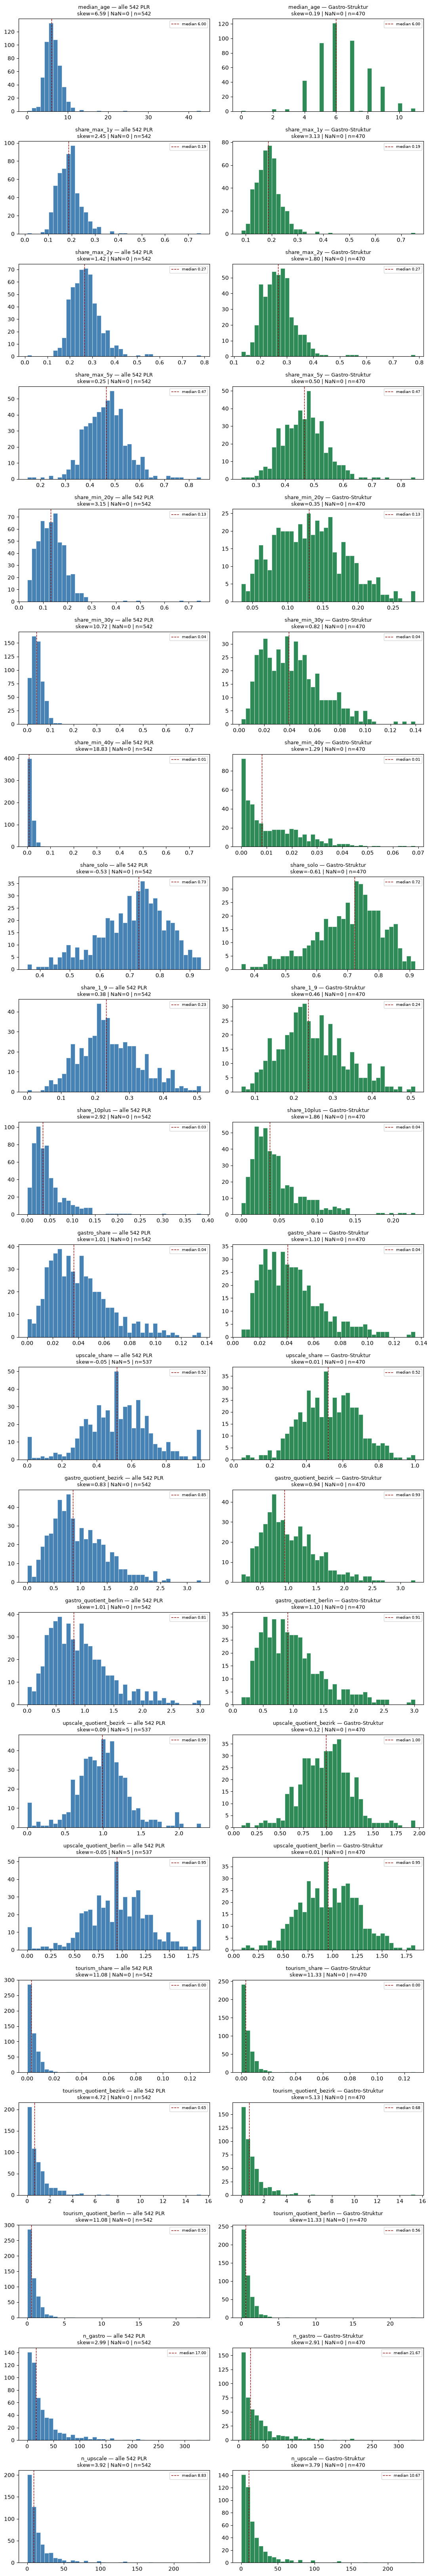

In [4]:
# side-by-side histograms: all 542 PLR (left) vs gastro-structure subset (right)
def hist_pair(col, ax_all, ax_sub):
    for ax, data, label, color in [
        (ax_all, df[col], "alle 542 PLR", "steelblue"),
        (ax_sub, cs[col], "Gastro-Struktur", "seagreen"),
    ]:
        d = data.dropna()
        ax.hist(d, bins=40, color=color, edgecolor="white", linewidth=0.4)
        if len(d):
            ax.axvline(d.median(), color="darkred", linestyle="--", linewidth=1,
                       label=f"median {d.median():.2f}")
            ax.legend(fontsize=7)
        skew = d.skew() if len(d) > 2 else float("nan")
        n_na = int(data.isna().sum())
        short = col.replace("com_", "").replace("_level_2026", "")
        ax.set_title(f"{short} — {label}\nskew={skew:.2f} | NaN={n_na} | n={len(d)}", fontsize=9)

n = len(level_vars)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.1 * n))
for i, col in enumerate(level_vars):
    hist_pair(col, axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()


### Schiefe-Übersicht (kompakt)

Tabellarisch, zum schnellen Überblick — welche Variablen sind asymmetrisch? Noch **keine** Konsequenz,
nur Beschreibung. (Hinweis: Schiefe ist v.a. für die rohen Counts und Quotienten aussagekräftig;
bei beschränkten Anteilen [0,1] und bei median_age mit Vorsicht zu lesen.)

In [ ]:
# compact skew table for both populations, sorted by |skew| of the full set
rows = []
for col in level_vars:
    d_all = df[col].dropna()
    d_sub = cs[col].dropna()
    rows.append({
        "variable": col.replace("com_", ""),
        "skew_all": round(d_all.skew(), 2) if len(d_all) > 2 else np.nan,
        "skew_sub": round(d_sub.skew(), 2) if len(d_sub) > 2 else np.nan,
        "median_all": round(d_all.median(), 3) if len(d_all) else np.nan,
        "NaN_all": int(df[col].isna().sum()),
    })
skew_tab = pd.DataFrame(rows).sort_values("skew_all", key=lambda s: s.abs(), ascending=False)
print(skew_tab.to_string(index=False))